In [1]:
from pathlib import Path

import pandas as pd
import missingno as msno
import numpy as np
import matplotlib.pyplot as plt

data_dir = Path("../data")

In [2]:
df = pd.read_csv(data_dir / "raw/metadata/AllClinical00.csv")
df2 = pd.read_csv(data_dir / "processed/variable_types.csv")

In [3]:
# Which columns have actual missing values
df.isna().sum().loc[lambda x: x > 0]

V00BLDHRS1      18
V00BLDHRS2    4767
V00BLSURD1    4791
V00BLSURD2    4796
V00hoursp1      38
              ... 
V00HOURWK     1826
V00MISSWK     1802
V00PASE         29
V00WEEKWK     1820
V00WKHR7CV       7
Length: 261, dtype: int64

In [4]:
blank   = df.isna()
coded   = df.astype(str).apply(lambda s: s.str.startswith(".:"))

# Cells with either type of missing
missing = blank | coded

summary = pd.DataFrame({
    "blank" : blank.sum(),
    "coded" : coded.sum(),
})

# 
summary = summary[summary.sum(axis=1) > 0]

summary["dataset"] = summary.index.map(df2.set_index("AllClinical00")["Dataset"])

print(summary.head())

            blank  coded     dataset
V00BLDHRS1     18      0  Biomarkers
V00BLDHRS2   4767      0  Biomarkers
V00BLDRAW2      0   4752  Biomarkers
V00BLSURD1   4791      0  Biomarkers
V00BLSURD2   4796      0  Biomarkers


In [5]:
summary["total_missing"] = (summary["blank"] + summary["coded"])

summary["missing_pct"] = summary["total_missing"] / len(df) * 100


summary.sort_values("missing_pct", ascending=False).head(50)

,blank,coded,dataset,total_missing,missing_pct
V00REASW8,0,4796,Physical Function,4796,100.000000
P02HR10,0,4796,Medical History,4796,100.000000
P02HR11,0,4796,Medical History,4796,100.000000
P01LRL3,4796,0,Medical History,4796,100.000000
V00LEXWHY3,0,4796,Physical Function,4796,100.000000
P01LRR3,4796,0,Medical History,4796,100.000000
P01HPNRDK,0,4796,Pain and Medication,4796,100.000000
V00DKP400W,0,4796,Physical Function,4796,100.000000
V00REASW15,0,4796,Physical Function,4796,100.000000
V00RFP400W,0,4796,Physical Function,4796,100.000000


In [6]:
dataset_missing = (
    summary.groupby("dataset").agg(
        columns=("dataset", "size"),
        total_missing=("total_missing", "sum"),
        avg_missing_pct=("missing_pct", "mean"),
    )
    .sort_values("avg_missing_pct", ascending=False)
)
dataset_missing

,columns,total_missing,avg_missing_pct
dataset,,,
Biomarkers,42,114863,57.023214
Comorbidity,28,62920,46.854522
Physical Function,170,359704,44.118138
Medical History,296,618999,43.603270
Pain and Medication,196,279508,29.734387
Physical Activity,18,14983,17.355898
Nutrition,279,192541,14.389306
Participant Characteristics,1,162,3.377815
KOOS/WOMAC,83,13247,3.327823


In [7]:
n = (summary["missing_pct"] > 80).sum()
print(f"{n} columns have more than 80% missing values")

296 columns have more than 80% missing values


In [8]:
#summary[summary["missing_pct"] > 80]

In [ ]:
def clean_column(series, col_type):
    s = series.replace(".: Missing Form/Incomplete Workbook", np.nan)
    if col_type == "Continuous":
        return pd.to_numeric(s, errors="coerce")
    extracted = s.astype(str).str.extract(r"^\s*(-?\d+)\s*:")[0]
    numeric = pd.to_numeric(extracted, errors="coerce")
    fallback = pd.to_numeric(s, errors="coerce")
    
    return numeric.fillna(fallback)

type_map = df2.set_index("AllClinical00")["Type"].to_dict()

df_clean = df.copy()

for col, t in type_map.items():
    if col in df_clean.columns:
        df_clean[col] = clean_column(df_clean[col], t)

In [11]:
df_clean.head()

,ID,VERSION,V00BLDCOLL,V00BLDHRS1,V00BLDHRS2,V00BLDRAW1,V00BLDRAW2,V00BLSURD1,V00BLSURD2,V00CITRATE,...,V00PASE4,V00PASE4HR,V00PASE5,V00PASE5HR,V00PASE6,V00PASE6HR,V00WEEKWK,V00WKHR7CV,V00WORK7,V00WORKAMT
0,9000099.0,NaN,1,35400.0,NaN,1,NaN,NaN,NaN,1,...,0,NaN,3.0,1.0,2.0,1.0,52.0,50.0,1.0,1.0
1,9000296.0,NaN,1,30780.0,NaN,1,NaN,NaN,NaN,1,...,0,NaN,0.0,NaN,0.0,NaN,52.0,50.0,1.0,2.0
2,9000622.0,NaN,1,33900.0,NaN,1,NaN,NaN,NaN,1,...,0,NaN,0.0,NaN,0.0,NaN,NaN,0.0,0.0,NaN
3,9000798.0,NaN,1,26400.0,NaN,1,NaN,NaN,NaN,1,...,0,NaN,0.0,NaN,0.0,NaN,52.0,40.0,1.0,3.0
4,9001104.0,NaN,1,35100.0,NaN,1,NaN,NaN,NaN,1,...,0,NaN,0.0,NaN,3.0,1.0,NaN,0.0,0.0,NaN


In [ ]:
P01OAGRDL
P01OAGRDR

<Axes: >

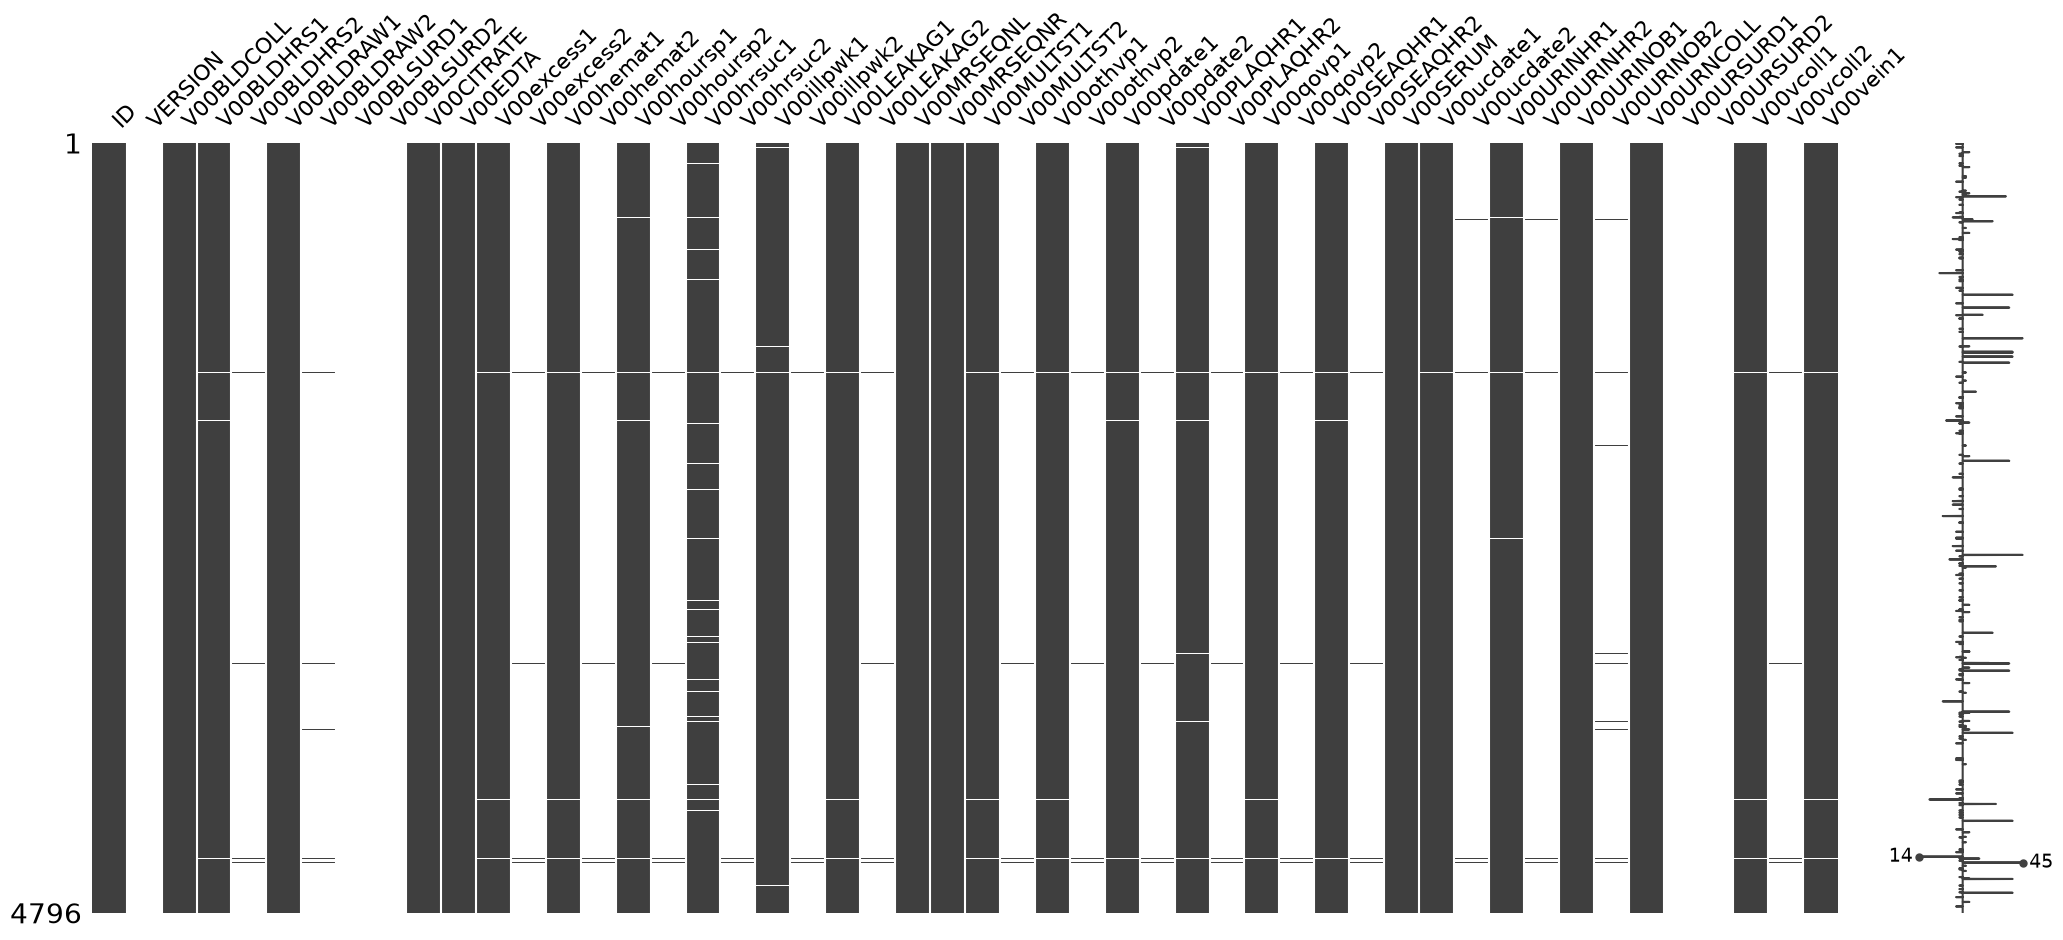

In [12]:
msno.matrix(df_clean.iloc[:, 0:50])
